# IEEE 57-Bus DC-OPF with Line Switching
**Author:** Jewook Park  
**Date:** October 2025  
**Description:** DC-OPF with binary line switching variables using Big-M method for IEEE 57-bus system


## Setup and Data Loading


In [1]:
import os
os.environ["GRB_LICENSE_FILE"] = "/Users/a/Desktop/VIP/sc-opf/API key/gurobi.lic"
import re
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
def extract_matrix_block(lines, varname):
    """Extract matrix data from MATPOWER .m file"""
    in_block = False
    matrix_lines = []

    for line in lines:
        if line.strip().startswith(f"{varname} = ["):
            in_block = True
            continue
        if in_block:
            if line.strip().startswith("];"):
                break
            clean = re.sub(r'%.*', '', line).strip().rstrip(';')
            if clean:
                matrix_lines.append(clean)

    matrix_data = []
    for line in matrix_lines:
        row = [float(x) for x in line.split()]
        matrix_data.append(row)
    
    return np.array(matrix_data)

# Load IEEE 57-bus system data
path = 'data/pglib_opf_case57_ieee.m'

with open(path, 'r') as f:
    lines = f.readlines()

bus = extract_matrix_block(lines, 'mpc.bus')
branch = extract_matrix_block(lines, 'mpc.branch')
gen = extract_matrix_block(lines, 'mpc.gen')
gencost = extract_matrix_block(lines, 'mpc.gencost')

bus_df = pd.DataFrame(bus, columns=[
    'bus_i','type','Pd','Qd','Gs','Bs','area','Vm','Va','baseKV','zone','Vmax','Vmin'
])
gen_df = pd.DataFrame(gen, columns=[
    'bus','Pg','Qg','Qmax','Qmin','Vg','mBase','status','Pmax','Pmin'
])
branch_df = pd.DataFrame(branch, columns=[
    'fbus','tbus','r','x','b','rateA','rateB','rateC',
    'ratio','angle','status','angmin','angmax'
])
gencost_df = pd.DataFrame(gencost, columns=[
    'model','startup','shutdown','n','c2','c1','c0'
])

print(f"Loaded IEEE 57-bus system:")
print(f"  Buses: {len(bus_df)}")
print(f"  Branches: {len(branch_df)}")
print(f"  Generators: {len(gen_df)}")
print(f"  Total Load: {bus_df['Pd'].sum():.2f} MW")


Loaded IEEE 57-bus system:
  Buses: 57
  Branches: 80
  Generators: 7
  Total Load: 1250.80 MW


## DC-OPF Model with Line Switching


In [3]:
def solve_dc_opf_with_switching(bus_df, gen_df, branch_df, gencost_df, verbose=True):
    """
    Solve DC-OPF with line switching using Big-M method
    Binary variable z[i]: 1 if line i is on, 0 if off
    """
    model = gp.Model("DC-OPF-LineSwitching-Case57")
    if not verbose:
        model.Params.OutputFlag = 0
    
    # Reference bus
    ref_bus = bus_df[bus_df['type'] == 3]['bus_i'].values[0]
    
    # Big-M value for switching constraints
    M = 1000
    
    # Variables
    Pg = model.addVars(gen_df.index, lb=0, name="Pg")
    theta = model.addVars(bus_df['bus_i'], lb=-GRB.INFINITY, name="theta")
    P_branch = model.addVars(branch_df.index, lb=-GRB.INFINITY, name="P_branch")
    z = model.addVars(branch_df.index, vtype=GRB.BINARY, name="z")  # Line switching binary
    
    # Objective: Minimize generation cost
    obj = gp.QuadExpr()
    for idx, row in gencost_df.iterrows():
        obj += row['c2'] * Pg[idx]*Pg[idx] + row['c1'] * Pg[idx] + row['c0']
    model.setObjective(obj, GRB.MINIMIZE)
    
    # Constraints
    
    # 1. Reference bus angle
    model.addConstr(theta[ref_bus] == 0, name="ref_bus")
    
    # 2. Generator limits
    for idx, row in gen_df.iterrows():
        model.addConstr(Pg[idx] >= row['Pmin'], name=f"Pg_min_{idx}")
        model.addConstr(Pg[idx] <= row['Pmax'], name=f"Pg_max_{idx}")
    
    # 3. DC power flow with Big-M for switching
    for idx, row in branch_df.iterrows():
        fbus = row['fbus']
        tbus = row['tbus']
        x = row['x']
        B = 1.0 / x  # Susceptance
        
        # P_ij = B * (theta_i - theta_j) when z=1
        # P_ij = 0 when z=0
        model.addConstr(
            P_branch[idx] - B * (theta[fbus] - theta[tbus]) <= M * (1 - z[idx]),
            name=f"flow_up_{idx}"
        )
        model.addConstr(
            P_branch[idx] - B * (theta[fbus] - theta[tbus]) >= -M * (1 - z[idx]),
            name=f"flow_lo_{idx}"
        )
        # Force flow to zero when line is off
        model.addConstr(P_branch[idx] <= M * z[idx], name=f"off_up_{idx}")
        model.addConstr(P_branch[idx] >= -M * z[idx], name=f"off_lo_{idx}")
    
    # 4. Line capacity limits (only when line is on)
    for idx, row in branch_df.iterrows():
        rateA = row['rateA']
        if rateA > 0:
            model.addConstr(P_branch[idx] <= rateA * z[idx], name=f"cap_up_{idx}")
            model.addConstr(P_branch[idx] >= -rateA * z[idx], name=f"cap_lo_{idx}")
    
    # 5. Power balance at each bus
    for idx, row in bus_df.iterrows():
        bus = row['bus_i']
        Pd = row['Pd']
        
        gen_at_bus = gen_df[gen_df['bus'] == bus].index.tolist()
        gen_P = gp.quicksum(Pg[g] for g in gen_at_bus) if gen_at_bus else 0
        
        branch_out = gp.quicksum(
            P_branch[br] for br in branch_df[branch_df['fbus'] == bus].index
        )
        branch_in = gp.quicksum(
            P_branch[br] for br in branch_df[branch_df['tbus'] == bus].index
        )
        
        model.addConstr(gen_P - Pd == branch_out - branch_in, name=f"balance_{bus}")
    
    # Solve
    model.optimize()
    
    return model, Pg, theta, P_branch, z


In [4]:
# Solve with line switching
model, Pg, theta, P_branch, z = solve_dc_opf_with_switching(bus_df, gen_df, branch_df, gencost_df)


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2725033
Academic license 2725033 - for non-commercial use only - registered to jp___@gatech.edu
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Academic license 2725033 - for non-commercial use only - registered to jp___@gatech.edu
Optimize a model with 552 rows, 224 columns and 1462 nonzeros
Model fingerprint: 0x5f03db25
Variable types: 144 continuous, 80 integer (80 binary)
Coefficient statistics:
  Matrix range     [7e-01, 2e+03]
  Objective range  [2e+01, 4e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+00, 1e+03]
Presolve removed 240 rows and 38 columns
Presolve time: 0.00s
Presolved: 312 rows, 186 columns, 1045 nonzeros
Variable types: 107 continuous, 79 integer (79 binary)

Root relaxation: objective 3.477295e+04, 267 iterations, 0.00 seconds (0.0

## Results Analysis


In [5]:
if model.status == GRB.OPTIMAL:
    print("=" * 70)
    print("IEEE 57-BUS DC-OPF WITH LINE SWITCHING - RESULTS")
    print("Author: Jewook Park")
    print("=" * 70)
    print(f"\nOptimal Cost: ${model.objVal:.2f}")
    print(f"Total Generation: {sum(Pg[i].X for i in gen_df.index):.2f} MW")
    print(f"Total Load: {bus_df['Pd'].sum():.2f} MW")
    
    # Line switching analysis
    lines_on = sum(z[i].X > 0.5 for i in branch_df.index)
    lines_off = len(branch_df) - lines_on
    print(f"\nLine Switching Status:")
    print(f"  Lines ON: {lines_on} / {len(branch_df)}")
    print(f"  Lines OFF: {lines_off} / {len(branch_df)}")
    print(f"  Percentage ON: {lines_on/len(branch_df)*100:.1f}%")
    
    # Show which lines are switched off
    if lines_off > 0:
        print(f"\nLines Switched OFF:")
        for idx in branch_df.index:
            if z[idx].X < 0.5:
                fbus = int(branch_df.loc[idx, 'fbus'])
                tbus = int(branch_df.loc[idx, 'tbus'])
                print(f"  Line {idx}: {fbus} -> {tbus}")
else:
    print(f"Optimization failed with status: {model.status}")


IEEE 57-BUS DC-OPF WITH LINE SWITCHING - RESULTS
Author: Jewook Park

Optimal Cost: $34772.95
Total Generation: 1250.80 MW
Total Load: 1250.80 MW

Line Switching Status:
  Lines ON: 60 / 80
  Lines OFF: 20 / 80
  Percentage ON: 75.0%

Lines Switched OFF:
  Line 6: 6 -> 8
  Line 10: 9 -> 12
  Line 11: 9 -> 13
  Line 12: 13 -> 14
  Line 14: 1 -> 15
  Line 22: 10 -> 12
  Line 34: 24 -> 25
  Line 35: 24 -> 25
  Line 36: 24 -> 26
  Line 37: 26 -> 27
  Line 51: 36 -> 40
  Line 52: 22 -> 38
  Line 53: 11 -> 41
  Line 54: 41 -> 42
  Line 57: 15 -> 45
  Line 61: 48 -> 49
  Line 65: 13 -> 49
  Line 71: 44 -> 45
  Line 72: 40 -> 56
  Line 73: 56 -> 41


## Visualization


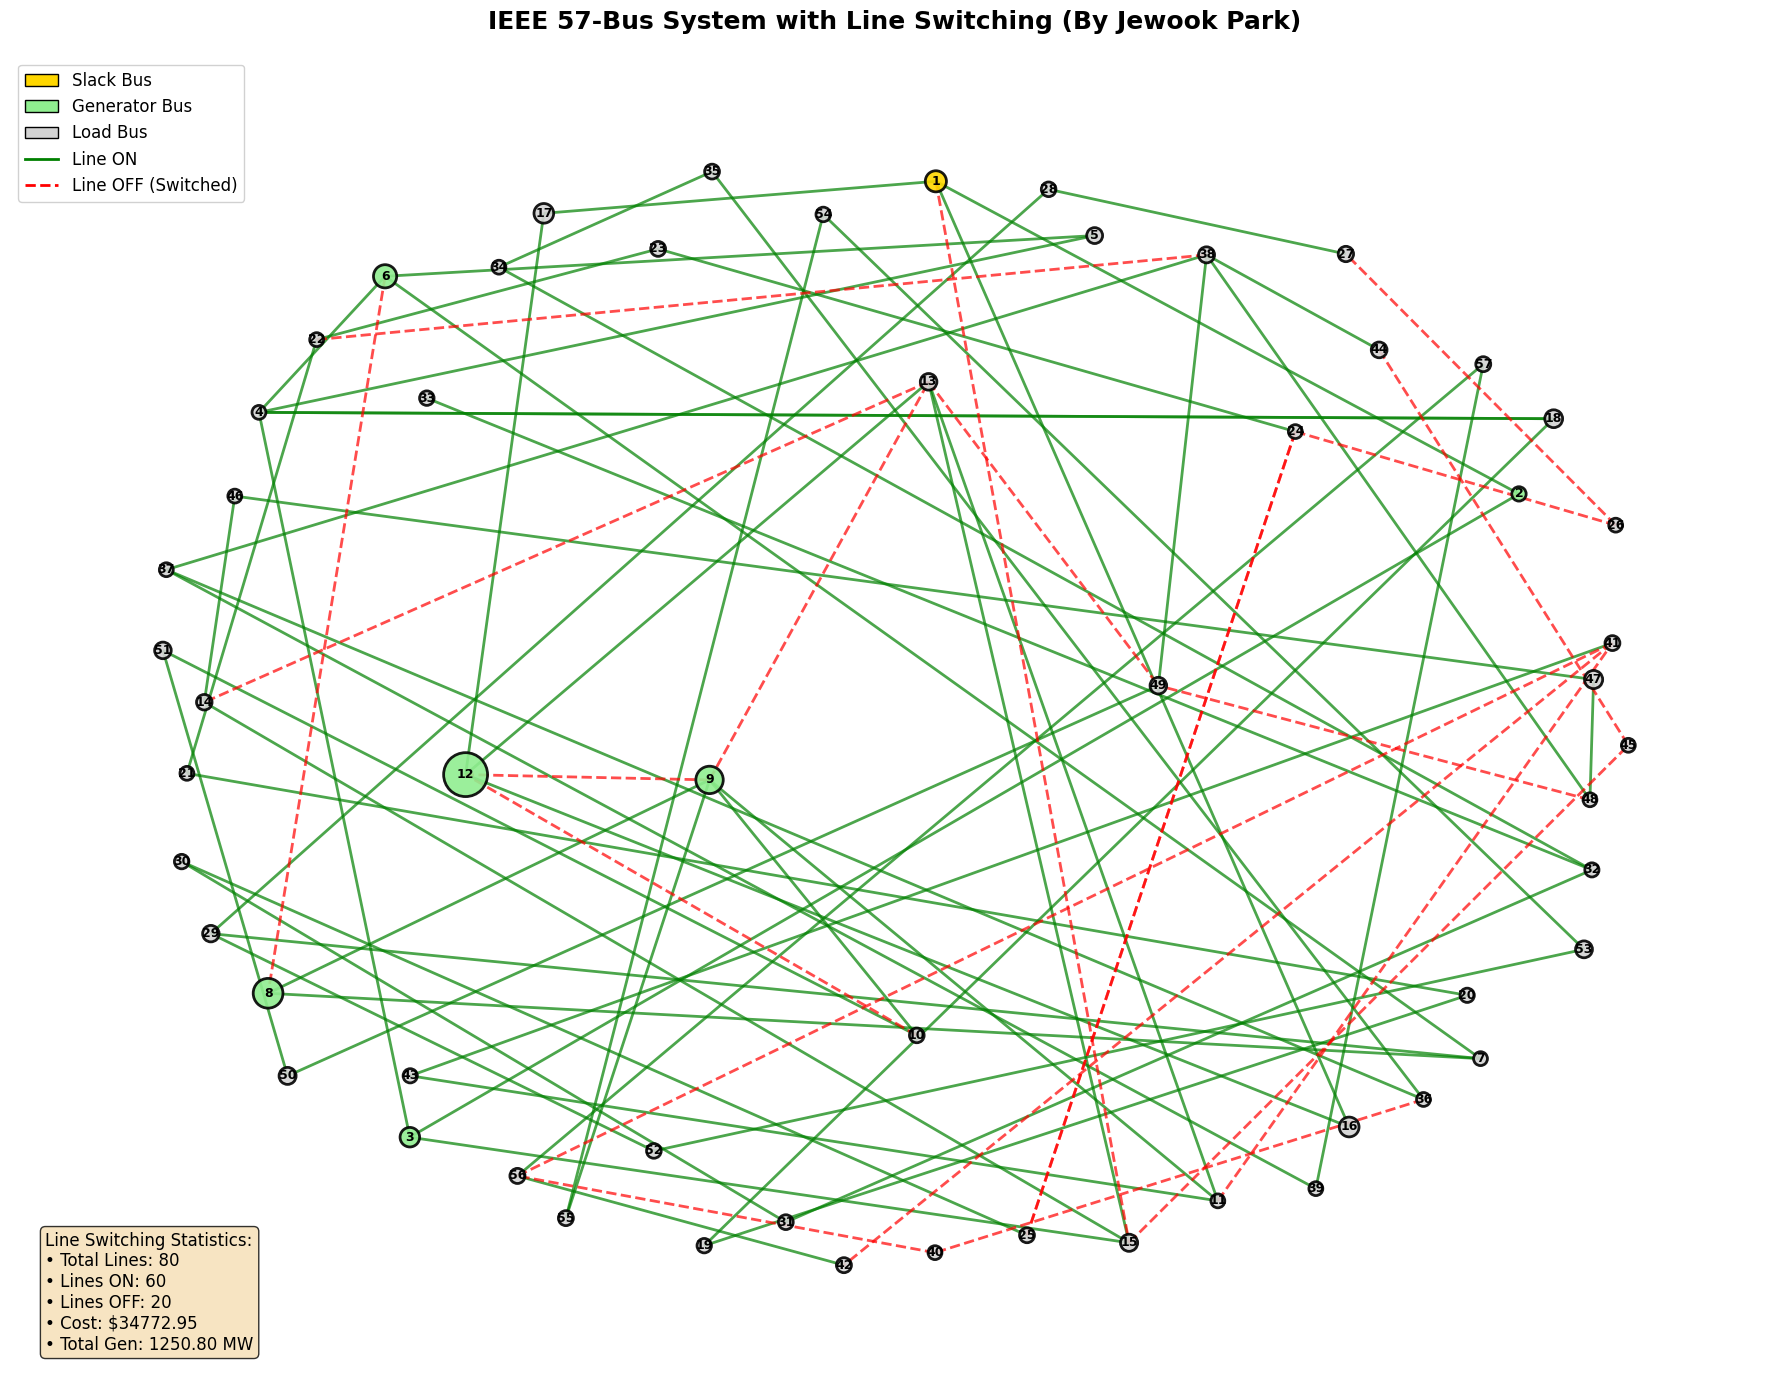

In [6]:
# Network topology with line switching visualization
G = nx.Graph()

# Add nodes
for idx, row in bus_df.iterrows():
    bus = int(row['bus_i'])
    G.add_node(bus, load=row['Pd'], bus_type=row['type'])

# Add edges with switching status
edges_on = []
edges_off = []
for idx, row in branch_df.iterrows():
    fbus = int(row['fbus'])
    tbus = int(row['tbus'])
    if model.status == GRB.OPTIMAL:
        if z[idx].X > 0.5:
            edges_on.append((fbus, tbus))
        else:
            edges_off.append((fbus, tbus))
    else:
        edges_on.append((fbus, tbus))
    G.add_edge(fbus, tbus)

# Node colors
node_colors = []
for node in G.nodes():
    bus_type = bus_df[bus_df['bus_i'] == node]['type'].values[0]
    if bus_type == 3:
        node_colors.append('gold')
    elif bus_type == 2:
        node_colors.append('lightgreen')
    else:
        node_colors.append('lightgray')

# Node sizes
node_sizes = []
for node in G.nodes():
    load = bus_df[bus_df['bus_i'] == node]['Pd'].values[0]
    size = 100 + (load / bus_df['Pd'].max() * 900) if bus_df['Pd'].max() > 0 else 300
    node_sizes.append(size)

# Plot
fig, ax = plt.subplots(figsize=(18, 14))
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                      alpha=0.9, linewidths=2, edgecolors='black', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)

# Draw edges - ON (green), OFF (red dashed)
if edges_on:
    nx.draw_networkx_edges(G, pos, edgelist=edges_on, edge_color='green',
                          width=2, alpha=0.7, ax=ax)
if edges_off:
    nx.draw_networkx_edges(G, pos, edgelist=edges_off, edge_color='red',
                          width=2, alpha=0.7, style='dashed', ax=ax)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='gold', edgecolor='black', label='Slack Bus'),
    Patch(facecolor='lightgreen', edgecolor='black', label='Generator Bus'),
    Patch(facecolor='lightgray', edgecolor='black', label='Load Bus'),
    Line2D([0], [0], color='green', linewidth=2, label='Line ON'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Line OFF (Switched)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

# Statistics
if model.status == GRB.OPTIMAL:
    stats_text = f"""Line Switching Statistics:
• Total Lines: {len(branch_df)}
• Lines ON: {len(edges_on)}
• Lines OFF: {len(edges_off)}
• Cost: ${model.objVal:.2f}
• Total Gen: {sum(Pg[i].X for i in gen_df.index):.2f} MW"""
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
           fontsize=12, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.title('IEEE 57-Bus System with Line Switching (By Jewook Park)',
         fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()
